In [1]:
# ============================================================
# 🚗 PROJET FUTURE VISION TRANSPORT - OPENCLASSROOMS
# Segmentation sémantique pour véhicules autonomes
# ============================================================
# Cellule 1 : Imports
import os
import sys
import random
import json
import shutil
import zipfile
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import requests

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras  # ✅ Utiliser keras depuis TensorFlow
# OU si vous préférez :
# import tensorflow.keras as keras

# MLflow
import mlflow
import mlflow.keras
from mlflow.models.signature import infer_signature
from mlflow import MlflowClient
from mlflow.models.signature import ModelSignature
from mlflow.types import Schema, ColSpec, TensorSpec

# Pandas pour les analyses
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Vérification des versions
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ Keras version: {keras.__version__}")
print(f"✅ Python version: {sys.version}")

✅ TensorFlow version: 2.17.0
✅ Keras version: 3.12.0
✅ Python version: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


In [2]:
# ============================================================
# Configuration de base TensorFlow/Keras
# ============================================================

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"CUDA disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.17.0
Keras version: 3.12.0
CUDA disponible: []


In [3]:
# ============================================================
# Configuration des chemins (DÉFINITION UNIQUE)
# ============================================================

# ⚠️ ADAPTER CE CHEMIN À VOTRE CONFIGURATION
BASE_DIR = r"C:\Users\touad\Projects-Openclassrooms\Projet-Future-Vision-Transport"

# Sous-dossiers importants
DATA_DIR = os.path.join(BASE_DIR, "Data")
CITYSCAPES_DIR = os.path.join(DATA_DIR, "cityscapes")

# Création des dossiers nécessaires
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CITYSCAPES_DIR, exist_ok=True)

# Vérification
if not os.path.exists(CITYSCAPES_DIR):
    raise FileNotFoundError(f"❌ Cityscapes non trouvé : {CITYSCAPES_DIR}")

print(f"✅ Projet initialisé")
print(f"   📁 Base : {BASE_DIR}")
print(f"   📊 Cityscapes : {CITYSCAPES_DIR}")

✅ Projet initialisé
   📁 Base : C:\Users\touad\Projects-Openclassrooms\Projet-Future-Vision-Transport
   📊 Cityscapes : C:\Users\touad\Projects-Openclassrooms\Projet-Future-Vision-Transport\Data\cityscapes


In [4]:
# ============================================================
# Configuration de la reproductibilité
# ============================================================

# Configuration des graines aléatoires
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ Graine aléatoire définie : {SEED}")

✅ Graine aléatoire définie : 42


In [5]:
# ============================================================
# Configuration MLflow
# ============================================================

from dotenv import load_dotenv

# Charger les variables depuis .env (si présent)
load_dotenv(os.path.join(BASE_DIR, ".env"))

mlflow_tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
aws_access_key_id = os.getenv("AWS_ACCESS_KEY_ID", "")
aws_secret_access_key = os.getenv("AWS_SECRET_ACCESS_KEY", "")

# Configuration MLflow
mlflow.set_tracking_uri(mlflow_tracking_uri)
print(f"✅ MLflow Tracking URI: {mlflow_tracking_uri}")

# Config AWS (si utile)
if aws_access_key_id and aws_secret_access_key:
    os.environ["AWS_ACCESS_KEY_ID"] = aws_access_key_id
    os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret_access_key
    print("✅ Identifiants AWS configurés")
else:
    print("⚠️ Aucun identifiant AWS trouvé (non nécessaire si MLflow local)")

# Créer l'expérience MLflow
mlflow.set_experiment("OC Projet 8")

✅ MLflow Tracking URI: http://127.0.0.1:5000
⚠️ Aucun identifiant AWS trouvé (non nécessaire si MLflow local)


<Experiment: artifact_location='mlflow-artifacts:/992620956726967536', creation_time=1760983823640, experiment_id='992620956726967536', last_update_time=1760983823640, lifecycle_stage='active', name='OC Projet 8', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [6]:
# ============================================================
# Paramètres globaux
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

print(f"📐 Taille des images : {IMG_SIZE}")
print(f"📦 Taille des batchs : {BATCH_SIZE}")

📐 Taille des images : (224, 224)
📦 Taille des batchs : 8


In [7]:
# ============================================================
# Définition des classes Cityscapes
# ============================================================

# Définition des classes Cityscapes par groupe
class_groups = {
    'flat': ['road', 'sidewalk', 'parking', 'rail track'],
    'human': ['person', 'rider'],
    'vehicle': ['car', 'truck', 'bus', 'on rails', 'motorcycle', 'bicycle', 'caravan', 'trailer'],
    'construction': ['building', 'wall', 'fence', 'guard rail', 'bridge', 'tunnel'],
    'object': ['pole', 'pole group', 'traffic sign', 'traffic light'],
    'nature': ['vegetation', 'terrain'],
    'sky': ['sky'],
    'void': ['unlabeled', 'ego vehicle', 'rectification border', 'out of roi', 'static', 'dynamic', 'ground']
}

# Définition du mapping entre les ID originaux de Cityscapes et nos groupes
cityscapes_mapping = {
    # void
    0: 7, 1: 7, 2: 7, 3: 7, 4: 7, 5: 7, 6: 7,
    # flat
    7: 0, 8: 0, 9: 0, 10: 0,
    # construction
    11: 3, 12: 3, 13: 3, 14: 3, 15: 3, 16: 3,
    # object
    17: 4, 18: 4, 19: 4, 20: 4,
    # nature
    21: 5, 22: 5,
    # sky
    23: 6,
    # human
    24: 1, 25: 1,
    # vehicle
    26: 2, 27: 2, 28: 2, 29: 2, 30: 2, 31: 2, 32: 2, 33: 2,
}

# Création d'un tableau pour faciliter la conversion des ID
id_to_group = np.zeros(256, dtype=np.uint8)
for id_val, group_id in cityscapes_mapping.items():
    id_to_group[id_val] = group_id

# Définition des couleurs pour la visualisation des groupes
group_colors = [
    [128, 64, 128],  # flat - bleu-gris
    [220, 20, 60],   # human - rouge
    [0, 0, 142],     # vehicle - bleu foncé
    [70, 70, 70],    # construction - gris
    [220, 220, 0],   # object - jaune
    [107, 142, 35],  # nature - vert
    [70, 130, 180],  # sky - bleu ciel
    [0, 0, 0]        # void - noir
]

# Noms des groupes
group_names = ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']
num_classes = len(group_names)

print(f"✅ {num_classes} classes définies : {group_names}")

✅ 8 classes définies : ['flat', 'human', 'vehicle', 'construction', 'object', 'nature', 'sky', 'void']


In [8]:
# ============================================================
# Fonctions de préparation du dataset (VERSION CORRIGÉE)
# ============================================================

def prepare_dataset_with_split(dataset_path, split='train', batch_size=8, 
                               img_size=(224, 224), validation_split=0.2,
                               id_to_group=None):
    """
    Prépare un dataset avec division automatique train/validation
    ✅ CORRECTION : drop_remainder=True pour batches de taille fixe
    """
    
    # ✅ Validation du paramètre obligatoire
    if id_to_group is None:
        raise ValueError("⚠️ Le paramètre 'id_to_group' est obligatoire !")
    
    images_dir = os.path.join(dataset_path, 'leftImg8bit', split)
    masks_dir = os.path.join(dataset_path, 'gtFine', split)
    
    image_paths = []
    mask_paths = []
    
    for city in os.listdir(images_dir):
        city_img_dir = os.path.join(images_dir, city)
        city_mask_dir = os.path.join(masks_dir, city)
        
        for file_name in os.listdir(city_img_dir):
            if file_name.endswith('_leftImg8bit.png'):
                img_path = os.path.join(city_img_dir, file_name)
                mask_name = file_name.replace('_leftImg8bit.png', '_gtFine_labelIds.png')
                mask_path = os.path.join(city_mask_dir, mask_name)
                
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
    
    print(f"{split} dataset: {len(image_paths)} images found")
    
    if split == 'train' and validation_split > 0:
        combined = list(zip(image_paths, mask_paths))
        random.seed(42)
        random.shuffle(combined)
        image_paths, mask_paths = zip(*combined)
        
        total_samples = len(image_paths)
        val_samples = int(total_samples * validation_split)
        train_samples = total_samples - val_samples
        
        train_img_paths = list(image_paths[:train_samples])
        train_mask_paths = list(mask_paths[:train_samples])
        val_img_paths = list(image_paths[train_samples:])
        val_mask_paths = list(mask_paths[train_samples:])
        
        print(f"  └─ Train: {len(train_img_paths)} images")
        print(f"  └─ Validation: {len(val_img_paths)} images")
        
        train_dataset = create_dataset_from_paths(
            train_img_paths, train_mask_paths, batch_size, img_size, 
            id_to_group=id_to_group, augment=True
        )
        val_dataset = create_dataset_from_paths(
            val_img_paths, val_mask_paths, batch_size, img_size,
            id_to_group=id_to_group, augment=False
        )
        
        return train_dataset, val_dataset
    
    else:
        dataset = create_dataset_from_paths(
            image_paths, mask_paths, batch_size, img_size,
            id_to_group=id_to_group, augment=False
        )
        return dataset


def create_dataset_from_paths(image_paths, mask_paths, batch_size, img_size, 
                              id_to_group, augment=False):
    """
    Crée un dataset TensorFlow à partir de listes de chemins
    ✅ CORRECTION : drop_remainder=True pour éviter les erreurs de shape
    """
    
    path_dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    def load_and_preprocess(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, img_size, method='bilinear')
        img = tf.cast(img, tf.float32) / 255.0
        
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)
        mask = tf.image.resize(mask, img_size, method='nearest')
        mask = tf.cast(mask, tf.int32)
        
        flat_mask = tf.reshape(mask, [-1])
        mapped_mask = tf.gather(tf.constant(id_to_group, dtype=tf.int32), flat_mask)
        mask = tf.reshape(mapped_mask, tf.shape(mask))
        mask = tf.squeeze(mask, axis=-1)
        
        return img, mask
    
    dataset = path_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        def augment_data(image, mask):
            mask = tf.expand_dims(mask, axis=-1)
            
            if tf.random.uniform(()) > 0.5:
                image = tf.image.flip_left_right(image)
                mask = tf.image.flip_left_right(mask)
            
            image = tf.image.random_brightness(image, 0.1)
            image = tf.clip_by_value(image, 0, 1)
            
            mask = tf.squeeze(mask, axis=-1)
            
            return image, mask
        
        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    
    # ✅ CORRECTION CRITIQUE : drop_remainder=True pour taille de batch fixe
    dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("✅ Fonctions de préparation du dataset définies (avec drop_remainder=True)")

✅ Fonctions de préparation du dataset définies (avec drop_remainder=True)


In [9]:
# ============================================================
# Visualisation d'échantillons
# ============================================================

def display_sample(dataset, num_samples=2):
    """Affiche un échantillon d'images et de masques d'un dataset TensorFlow."""
    
    for batch in dataset.take(1):
        images, masks = batch
        
        num_to_display = min(num_samples, images.shape[0])
        
        fig, axes = plt.subplots(num_to_display, 3, figsize=(15, 5*num_to_display))
        
        if num_to_display == 1:
            axes = axes.reshape(1, -1)
        
        for i in range(num_to_display):
            image = images[i]
            mask = masks[i]
            
            axes[i, 0].imshow((image.numpy() * 255).astype("uint8"))
            axes[i, 0].set_title("Image Originale")
            axes[i, 0].axis("off")
            
            axes[i, 1].imshow(mask.numpy(), cmap='tab10', vmin=0, vmax=num_classes-1)
            axes[i, 1].set_title("Masque (IDs de classes)")
            axes[i, 1].axis("off")
            
            mask_array = mask.numpy()
            colored_mask = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
            
            for group_id in range(num_classes):
                colored_mask[mask_array == group_id] = group_colors[group_id]
            
            axes[i, 2].imshow(colored_mask)
            axes[i, 2].set_title("Masque Segmenté (Coloré)")
            axes[i, 2].axis("off")
        
        plt.tight_layout()
        plt.show()
        
        unique_classes, counts = np.unique(masks[0].numpy(), return_counts=True)
        print("\nClasses présentes dans la première image:")
        for class_id, count in zip(unique_classes, counts):
            percentage = (count / masks[0].numpy().size) * 100
            print(f"  {group_names[class_id]}: {count} pixels ({percentage:.1f}%)")

print("✅ Fonction de visualisation définie")

✅ Fonction de visualisation définie


In [10]:
# ============================================================
# Métrique IoU custom (compatible avec la segmentation)
# ============================================================

class CustomMeanIoU(keras.metrics.Metric):
    """
    Métrique IoU custom pour éviter les problèmes de shape avec keras.metrics.MeanIoU
    Compatible avec la segmentation sémantique
    """
    def __init__(self, num_classes, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=-1)
        y_true_flat = tf.reshape(y_true, [-1])
        y_pred_flat = tf.reshape(y_pred_classes, [-1])
        
        iou_sum = 0.0
        valid_classes = 0
        
        for class_id in range(self.num_classes):
            true_class = tf.equal(y_true_flat, class_id)
            pred_class = tf.equal(y_pred_flat, class_id)
            
            intersection = tf.reduce_sum(tf.cast(tf.logical_and(true_class, pred_class), tf.float32))
            union = tf.reduce_sum(tf.cast(tf.logical_or(true_class, pred_class), tf.float32))
            
            iou = tf.cond(union > 0, lambda: intersection / union, lambda: 0.0)
            
            class_exists = tf.reduce_any(true_class)
            iou_sum += tf.cond(class_exists, lambda: iou, lambda: 0.0)
            valid_classes += tf.cond(class_exists, lambda: 1.0, lambda: 0.0)
        
        mean_iou = tf.cond(valid_classes > 0, lambda: iou_sum / valid_classes, lambda: 0.0)
        
        self.total_iou.assign_add(mean_iou)
        self.count.assign_add(1.0)
    
    def result(self):
        return tf.cond(self.count > 0, lambda: self.total_iou / self.count, lambda: 0.0)
    
    def reset_state(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)

print("✅ Métrique IoU custom définie")

✅ Métrique IoU custom définie


In [11]:
# ============================================================
# Architecture MiniUNet (baseline from scratch)
# ============================================================

def build_mini_unet(input_shape=(224, 224, 3), num_classes=8):
    """Version simplifiée du U-Net entraînée from scratch."""
    from tensorflow.keras import layers, Model
    
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)
    
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)
    
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D(2)(c3)
    
    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)
    
    # Decoder
    u3 = layers.UpSampling2D(2)(b)
    u3 = layers.concatenate([u3, c3])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)
    
    u2 = layers.UpSampling2D(2)(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(c5)
    
    u1 = layers.UpSampling2D(2)(c5)
    u1 = layers.concatenate([u1, c1])
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(16, 3, activation='relu', padding='same')(c6)
    
    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c6)
    
    model = Model(inputs, outputs, name="MiniUNet")
    
    # Compilation avec CustomMeanIoU
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[
            CustomMeanIoU(num_classes=num_classes, name='iou'),
            keras.metrics.SparseCategoricalAccuracy(name='accuracy')
        ]
    )
    
    return model

print("✅ Architecture MiniUNet définie (avec CustomMeanIoU)")

✅ Architecture MiniUNet définie (avec CustomMeanIoU)


In [12]:
# ============================================================
# Architecture MobileNetV2-UNet (AVEC ANIMATION COMPLÈTE)
# ============================================================

def create_segmentation_model(num_classes=8, input_size=(224, 224, 3),
                            learning_rate=0.0001, base_trainable=False):
    """Create a segmentation model with configurable parameters"""
    
    import time
    import sys
    from threading import Thread, Event
    
    # Fonction d'animation de chargement
    def animate_loading(message, stop_event):
        """Affiche une animation pendant le chargement"""
        frames = ['⠋', '⠙', '⠹', '⠸', '⠼', '⠴', '⠦', '⠧', '⠇', '⠏']
        idx = 0
        while not stop_event.is_set():
            sys.stdout.write(f'\r      {frames[idx]} {message}')
            sys.stdout.flush()
            idx = (idx + 1) % len(frames)
            time.sleep(0.1)
        sys.stdout.write('\r' + ' ' * 80 + '\r')
        sys.stdout.flush()
    
    # Fonction d'animation rapide
    def quick_animate(message):
        """Animation rapide pour les opérations courtes"""
        frames = ['⠋', '⠙', '⠹', '⠸', '⠼']
        for frame in frames:
            sys.stdout.write(f'\r      {frame} {message}')
            sys.stdout.flush()
            time.sleep(0.05)
        sys.stdout.write('\r' + ' ' * 80 + '\r')
        sys.stdout.flush()
    
    print("\n" + "="*70)
    print("🏗️ CONSTRUCTION DU MODÈLE MobileNetV2-UNet")
    print("="*70)
    
    # ========== ÉTAPE 1/5 : Input Layer ==========
    print("\n[1/5] 📐 Création de l'input layer...")
    start = time.time()
    inputs = keras.layers.Input(shape=input_size)
    print(f"      ✅ Terminé en {time.time()-start:.2f}s")
    
    # ========== ÉTAPE 2/5 : MobileNetV2 (avec animation) ==========
    print("\n[2/5] 📥 Chargement de MobileNetV2 ImageNet...")
    print("      ⏳ Premier chargement: 30s-3min (téléchargement 14 MB)")
    print("      ⏳ Chargements suivants: < 5s (depuis cache)")
    print()
    
    # Démarrer l'animation
    stop_animation = Event()
    animation_thread = Thread(target=animate_loading, args=("Téléchargement en cours...", stop_animation))
    animation_thread.daemon = True
    animation_thread.start()
    
    start = time.time()
    try:
        base_model = keras.applications.MobileNetV2(
            input_shape=input_size,
            include_top=False,
            weights='imagenet'
        )
        elapsed = time.time() - start
        
        # Arrêter l'animation
        stop_animation.set()
        animation_thread.join(timeout=0.5)
        
        print(f"      ✅ MobileNetV2 chargé avec succès en {elapsed:.1f}s")
        
        if elapsed < 5:
            print("      💡 Rapide → Poids chargés depuis le cache local")
        else:
            print("      💡 Long → Poids téléchargés depuis Internet")
            
    except Exception as e:
        # Arrêter l'animation en cas d'erreur
        stop_animation.set()
        animation_thread.join(timeout=0.5)
        
        print(f"\n      ❌ ERREUR: {e}")
        print("      🔄 Basculement sur poids aléatoires...")
        base_model = keras.applications.MobileNetV2(
            input_shape=input_size,
            include_top=False,
            weights=None
        )
        print("      ⚠️ Modèle créé sans pré-entraînement ImageNet")
    
    base_model.trainable = base_trainable
    print(f"      🔒 Encoder trainable: {base_trainable}")
    
    # ========== ÉTAPE 3/5 : Skip Connections ==========
    print("\n[3/5] 🔗 Extraction des skip connections...")
    start = time.time()
    
    skip1 = base_model.get_layer('block_1_expand_relu').output
    skip2 = base_model.get_layer('block_3_expand_relu').output
    skip3 = base_model.get_layer('block_6_expand_relu').output
    skip4 = base_model.get_layer('block_13_expand_relu').output
    bottleneck = base_model.get_layer('block_16_project').output
    
    encoder = keras.Model(inputs=base_model.input, outputs=[skip1, skip2, skip3, skip4, bottleneck])
    print(f"      ✅ Encoder créé avec 5 sorties en {time.time()-start:.2f}s")
    
    # ========== ÉTAPE 4/5 : Decoder U-Net (avec animation) ==========
    print("\n[4/5] 🎨 Construction du decoder U-Net...")
    start_decoder = time.time()
    
    x = inputs
    skips = encoder(x)
    x = skips[4]
    
    # Decoder - Bloc 1
    quick_animate("Bloc 1/5 (256 filtres)...")
    x = keras.layers.Conv2DTranspose(256, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Concatenate()([x, skips[3]])
    x = keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    print("      ✅ Bloc 1/5 (256 filtres)")
    
    # Decoder - Bloc 2
    quick_animate("Bloc 2/5 (128 filtres)...")
    x = keras.layers.Conv2DTranspose(128, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Concatenate()([x, skips[2]])
    x = keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    print("      ✅ Bloc 2/5 (128 filtres)")
    
    # Decoder - Bloc 3
    quick_animate("Bloc 3/5 (64 filtres)...")
    x = keras.layers.Conv2DTranspose(64, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Concatenate()([x, skips[1]])
    x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    print("      ✅ Bloc 3/5 (64 filtres)")
    
    # Decoder - Bloc 4
    quick_animate("Bloc 4/5 (32 filtres)...")
    x = keras.layers.Conv2DTranspose(32, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Concatenate()([x, skips[0]])
    x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    print("      ✅ Bloc 4/5 (32 filtres)")
    
    # Decoder - Bloc 5
    quick_animate("Bloc 5/5 (16 filtres)...")
    x = keras.layers.Conv2DTranspose(16, 3, strides=2, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    print("      ✅ Bloc 5/5 (16 filtres)")
    
    # Couche de sortie
    outputs = keras.layers.Conv2D(num_classes, 1, padding='same', activation='softmax')(x)
    print(f"      ✨ Decoder complet en {time.time()-start_decoder:.2f}s")
    
    # ========== ÉTAPE 5/5 : Compilation (avec animation) ==========
    print("\n[5/5] ⚙️ Compilation du modèle...")
    
    # Animation pendant la compilation
    stop_compile = Event()
    compile_thread = Thread(target=animate_loading, args=("Compilation en cours...", stop_compile))
    compile_thread.daemon = True
    compile_thread.start()
    
    start = time.time()
    model = keras.Model(inputs=inputs, outputs=outputs, name="MobileNetV2-UNet")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            CustomMeanIoU(num_classes=num_classes, name='iou'),
            keras.metrics.SparseCategoricalAccuracy(name='accuracy')
        ]
    )
    
    stop_compile.set()
    compile_thread.join(timeout=0.5)
    
    print(f"      ✅ Compilation terminée en {time.time()-start:.2f}s")
    
    # ========== Résumé final avec animation ==========
    print("\n" + "="*70)
    message = "✅ MODÈLE PRÊT"
    for char in message:
        sys.stdout.write(char)
        sys.stdout.flush()
        time.sleep(0.05)
    print()
    print("="*70)
    print(f"📊 Paramètres totaux: {model.count_params():,}")
    print(f"📐 Architecture: {model.name}")
    print(f"🎯 Classes: {num_classes}")
    print(f"🔒 Base trainable: {base_trainable}")
    print(f"🎓 Learning rate: {learning_rate}")
    print("="*70 + "\n")
    
    return model

print("✅ Architecture MobileNetV2-UNet définie (avec CustomMeanIoU)")

✅ Architecture MobileNetV2-UNet définie (avec CustomMeanIoU)


In [13]:
# ============================================================
# VÉRIFICATION : Test de chargement du modèle
# ============================================================

print("🧪 TEST DE CHARGEMENT DU MODÈLE MobileNetV2-UNet")
print("=" * 70)

try:
    # Tenter de créer le modèle
    print("\n🔄 Tentative de création du modèle...")
    print("⏱️  Ceci va prendre 30s-3min si c'est la première fois\n")
    
    test_model = create_segmentation_model(
        num_classes=8,
        input_size=(224, 224, 3),
        learning_rate=0.0001,
        base_trainable=False
    )
    
    # Si on arrive ici, le modèle a été créé avec succès
    print("\n" + "=" * 70)
    print("✅ VÉRIFICATION RÉUSSIE")
    print("=" * 70)
    
    # Informations détaillées
    print(f"\n📊 Informations sur le modèle :")
    print(f"   • Nom : {test_model.name}")
    print(f"   • Nombre de couches : {len(test_model.layers)}")
    print(f"   • Paramètres totaux : {test_model.count_params():,}")
    print(f"   • Paramètres entraînables : {sum([tf.size(w).numpy() for w in test_model.trainable_weights]):,}")
    print(f"   • Paramètres non-entraînables : {sum([tf.size(w).numpy() for w in test_model.non_trainable_weights]):,}")
    
    # Vérifier les métriques
    print(f"\n🎯 Métriques configurées :")
    for metric in test_model.metrics:
        print(f"   • {metric.name} : {type(metric).__name__}")
    
    # Vérifier la forme des entrées/sorties
    print(f"\n📐 Architecture :")
    print(f"   • Input shape : {test_model.input_shape}")
    print(f"   • Output shape : {test_model.output_shape}")
    
    # Vérifier si MobileNetV2 a bien des poids pré-entraînés
    print(f"\n🔍 Vérification des poids pré-entraînés :")
    mobilenet_layer = None
    for layer in test_model.layers:
        if 'mobilenet' in layer.name.lower():
            mobilenet_layer = layer
            break
    
    if mobilenet_layer:
        # Vérifier si les poids sont différents de zéro (signe de pré-entraînement)
        weights = mobilenet_layer.get_weights()
        if len(weights) > 0:
            first_weight_sum = abs(weights[0].sum())
            if first_weight_sum > 0.01:
                print(f"   ✅ Poids ImageNet détectés (sum={first_weight_sum:.2f})")
                print(f"   💡 Le modèle utilise bien le pré-entraînement ImageNet")
            else:
                print(f"   ⚠️ Poids proches de zéro (sum={first_weight_sum:.6f})")
                print(f"   💡 Le modèle utilise probablement des poids aléatoires")
    
    # Test de prédiction (sans entraînement, juste pour vérifier que ça marche)
    print(f"\n🧠 Test de prédiction (forward pass) :")
    import numpy as np
    dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
    
    print(f"   • Création d'une image test de shape {dummy_input.shape}")
    prediction = test_model.predict(dummy_input, verbose=0)
    print(f"   • Prédiction réussie ! Shape : {prediction.shape}")
    print(f"   • Classes prédites : {prediction.argmax(axis=-1).flatten()[:10]}")
    
    # Vérifier que la somme des probabilités = 1 (softmax)
    prob_sum = prediction.sum(axis=-1).mean()
    print(f"   • Somme des probabilités : {prob_sum:.6f} (devrait être ~1.0)")
    
    if abs(prob_sum - 1.0) < 0.01:
        print(f"   ✅ Softmax fonctionne correctement")
    
    print("\n" + "=" * 70)
    print("🎉 TOUT FONCTIONNE PARFAITEMENT !")
    print("=" * 70)
    print("\n💡 Vous pouvez maintenant lancer l'entraînement (cellule 18)")
    
    # Nettoyer la mémoire
    print("\n🗑️ Nettoyage de la mémoire...")
    del test_model
    del dummy_input
    del prediction
    import gc
    gc.collect()
    print("   ✅ Mémoire libérée")
    
except Exception as e:
    print("\n" + "=" * 70)
    print("❌ ERREUR LORS DU CHARGEMENT")
    print("=" * 70)
    print(f"\n{type(e).__name__}: {str(e)}")
    print("\n📋 Traceback complet :")
    import traceback
    traceback.print_exc()
    print("\n💡 Suggestions :")
    print("   1. Vérifiez votre connexion Internet")
    print("   2. Vérifiez que la cellule CustomMeanIoU a été exécutée")
    print("   3. Essayez de relancer le kernel et ré-exécuter toutes les cellules")

🧪 TEST DE CHARGEMENT DU MODÈLE MobileNetV2-UNet

🔄 Tentative de création du modèle...
⏱️  Ceci va prendre 30s-3min si c'est la première fois


🏗️ CONSTRUCTION DU MODÈLE MobileNetV2-UNet

[1/5] 📐 Création de l'input layer...
      ✅ Terminé en 0.00s

[2/5] 📥 Chargement de MobileNetV2 ImageNet...
      ⏳ Premier chargement: 30s-3min (téléchargement 14 MB)
      ⏳ Chargements suivants: < 5s (depuis cache)

      ✅ MobileNetV2 chargé avec succès en 1.8s                                  
      💡 Rapide → Poids chargés depuis le cache local
      🔒 Encoder trainable: False

[3/5] 🔗 Extraction des skip connections...
      ✅ Encoder créé avec 5 sorties en 0.02s

[4/5] 🎨 Construction du decoder U-Net...
      ✅ Bloc 1/5 (256 filtres)                                                  
      ✅ Bloc 2/5 (128 filtres)                                                  
      ✅ Bloc 3/5 (64 filtres)                                                   
      ✅ Bloc 4/5 (32 filtres)                       

In [14]:
# ============================================================
# Configuration des expériences
# ============================================================

EXPERIMENTS = {
    "exp_001_miniunet": {
        "description": "MiniUNet baseline entraîné from scratch (aucun encoder pré-entraîné)",
        "model_builder": lambda: build_mini_unet(
            input_shape=(*IMG_SIZE, 3),
            num_classes=num_classes
        ),
        "params": {
            "learning_rate": 1e-3,
            "batch_size": 8,
            "epochs": 15,
            "base_model_trainable": True,
            "validation_split": 0.2,
            "augmentation": False
        }
    },
    
    "exp_002_no_augmentation": {
        "description": "MobileNetV2-UNet avec encoder gelé (pas de fine-tuning, pas d'augmentation)",
        "model_builder": lambda: create_segmentation_model(
            num_classes=num_classes,
            input_size=(*IMG_SIZE, 3),
            learning_rate=1e-4,
            base_trainable=False
        ),
        "params": {
            "learning_rate": 1e-4,
            "batch_size": 8,
            "epochs": 15,
            "base_model_trainable": False,
            "validation_split": 0.2,
            "augmentation": False
        }
    },
    
    "exp_003_finetune": {
        "description": "MobileNetV2-UNet avec encoder dégelé pour fine-tuning (lr=1e-5, data aug activée)",
        "model_builder": lambda: create_segmentation_model(
            num_classes=num_classes,
            input_size=(*IMG_SIZE, 3),
            learning_rate=1e-5,
            base_trainable=True
        ),
        "params": {
            "learning_rate": 1e-5,
            "batch_size": 8,
            "epochs": 10,
            "base_model_trainable": True,
            "validation_split": 0.2,
            "augmentation": True
        }
    }
}

print(f"✅ {len(EXPERIMENTS)} expériences configurées :")
for exp_name in EXPERIMENTS.keys():
    print(f"   • {exp_name}")

✅ 3 expériences configurées :
   • exp_001_miniunet
   • exp_002_no_augmentation
   • exp_003_finetune


In [15]:
# ============================================================
# Fonction de setup des dossiers d'expérience
# ============================================================

def setup_experiment_paths(base_dir, experiment_name):
    """Crée la structure de dossiers pour une expérience"""
    exp_dir = os.path.join(base_dir, "experiments", experiment_name)
    
    paths = {
        'exp_dir': exp_dir,
        'models_dir': os.path.join(exp_dir, 'models'),
        'checkpoints_dir': os.path.join(exp_dir, 'models', 'checkpoints'),
        'logs_dir': os.path.join(exp_dir, 'logs'),
        'results_dir': os.path.join(exp_dir, 'results'),
        'visualizations_dir': os.path.join(exp_dir, 'visualizations'),
    }
    
    for p in paths.values():
        os.makedirs(p, exist_ok=True)
    
    return paths

print("✅ Fonction setup_experiment_paths définie")

✅ Fonction setup_experiment_paths définie


In [16]:
# ============================================================
# Fonctions d'entraînement et de sauvegarde
# ============================================================

def train_model_with_config(model, train_dataset, val_dataset, config, paths, exp_name):
    """
    Entraîne le modèle avec une configuration donnée.
    Compatible avec le système multi-expériences (EXPERIMENTS).
    """
    params = config["params"]
    
    # ✅ Callbacks adaptés pour IoU
    callbacks = [
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_iou',  # ✅ Surveiller IoU
            factor=0.2,
            patience=2,
            verbose=1,
            min_lr=1e-6,
            mode='max'  # ✅ Maximiser IoU
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_iou',
            patience=5,
            restore_best_weights=True,
            verbose=1,
            mode='max'
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(paths['checkpoints_dir'], 'best_model.keras'),
            monitor='val_iou',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.TensorBoard(
            log_dir=os.path.join(paths['logs_dir'], datetime.now().strftime('%Y%m%d-%H%M%S')),
            histogram_freq=1
        )
    ]
    
    # MLflow Callback
    class ExperimentMLflowCallback(keras.callbacks.Callback):
        def __init__(self, config, paths, exp_name):
            super().__init__()
            self.config = config
            self.paths = paths
            self.exp_name = exp_name
        
        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            for name, value in logs.items():
                mlflow.log_metric(name, value, step=epoch)
        
        def on_train_begin(self, logs=None):
            mlflow.log_params(self.config["params"])
            mlflow.log_param("experiment_name", self.exp_name)
            mlflow.log_param("description", self.config["description"])
            mlflow.log_param("num_classes", num_classes)
            mlflow.log_param("img_size", IMG_SIZE)
    
    # Lancement MLflow
    mlflow.set_experiment("OC Projet 8")
    
    with mlflow.start_run(run_name=exp_name):
        mlflow_callback = ExperimentMLflowCallback(config, paths, exp_name)
        callbacks.append(mlflow_callback)
        
        print(f"🚀 Starting training for experiment: {exp_name}")
        print(f"📝 Description: {config['description']}")
        print(f"📊 Parameters: {params}")
        
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=params["epochs"],
            callbacks=callbacks,
            verbose=1
        )
        
        save_experiment_artifacts(model, history, config, paths)
        mlflow.log_artifacts(paths['results_dir'])
##################        mlflow.log_model
        
        return history

print("✅ Fonction train_model_with_config définie")



✅ Fonction train_model_with_config définie


In [17]:
# ============================================================
# Fonction de sauvegarde des artefacts (version corrigée)
# ============================================================

def save_experiment_artifacts(model, history, config, paths):
    """Sauvegarde tous les artefacts de l'expérience"""
    import copy

    # 🔹 Nettoyer la configuration (supprimer la fonction non sérialisable)
    safe_config = copy.deepcopy(config)
    if "model_builder" in safe_config:
        safe_config["model_builder"] = "custom_model_builder_function"

    # 1️⃣ Sauvegarder le modèle final
    final_model_path = os.path.join(paths['models_dir'], "cityscapes_segmentation_model.keras")
    model.save(final_model_path)
    print(f"💾 Modèle sauvegardé: {final_model_path}")

    # 2️⃣ Sauvegarder la configuration nettoyée
    #config_path = os.path.join(paths['results_dir'], "experiment_config.json")
    #with open(config_path, 'w', encoding='utf-8') as f:
    #    json.dump(safe_config, f, indent=4)

    # 3️⃣ Sauvegarder l'historique d'entraînement
    history_path = os.path.join(paths['results_dir'], "training_history.json")
    history_dict = {k: [float(v) for v in values] for k, values in history.history.items()}
    with open(history_path, 'w', encoding='utf-8') as f:
        json.dump(history_dict, f, indent=4)

    # 4️⃣ Graphiques d'apprentissage
    plt.figure(figsize=(18, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # ✅ IoU (métrique principale)
    plt.subplot(1, 3, 2)
    if 'iou' in history.history:
        plt.plot(history.history['iou'], label='Train IoU')
        plt.plot(history.history['val_iou'], label='Val IoU')
        plt.title('Model IoU (KPI Principal)')
        plt.xlabel('Epoch')
        plt.ylabel('IoU')
        plt.legend()
        plt.grid(True)

    # Accuracy (métrique secondaire)
    plt.subplot(1, 3, 3)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title('Model Accuracy (Secondaire)')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plots_path = os.path.join(paths['visualizations_dir'], 'training_plots.png')
    plt.savefig(plots_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"📊 Graphiques sauvegardés : {plots_path}")

    # 5️⃣ Sauvegarder le mapping des classes
    class_mapping = {
        'id_to_group': id_to_group.tolist(),
        'group_names': group_names,
        'group_colors': group_colors,
        'num_classes': num_classes
    }
    mapping_path = os.path.join(paths['models_dir'], 'class_mapping.json')
    with open(mapping_path, 'w', encoding='utf-8') as f:
        json.dump(class_mapping, f, indent=4)

    print(f"✅ Artefacts sauvegardés dans : {paths['exp_dir']}")

print("✅ Fonction save_experiment_artifacts corrigée et redéfinie")


✅ Fonction save_experiment_artifacts corrigée et redéfinie


In [18]:
# ============================================================
# Préparation des datasets (VERSION CONSOLIDÉE)
# ============================================================

print("=" * 80)
print("📦 PRÉPARATION DES DATASETS")
print("=" * 80)

# 1. Diviser le dataset 'train' original en train/val (80%/20%)
train_dataset, val_dataset = prepare_dataset_with_split(
    CITYSCAPES_DIR,
    split='train',
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    validation_split=0.2,
    id_to_group=id_to_group
)

# 2. Utiliser le dataset 'val' original comme dataset de test final
test_dataset = prepare_dataset_with_split(
    CITYSCAPES_DIR,
    split='val',  # L'ancien 'val' devient notre 'test'
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    id_to_group=id_to_group
)

print(f"\n✅ Datasets créés:")
print(f"   📚 Train: ~{2975 * 0.8:.0f} images (avec augmentation)")
print(f"   📊 Validation: ~{2975 * 0.2:.0f} images")
print(f"   🧪 Test: ~500 images (ancien dataset val)")
print("=" * 80)

📦 PRÉPARATION DES DATASETS
train dataset: 2975 images found
  └─ Train: 2380 images
  └─ Validation: 595 images
val dataset: 500 images found

✅ Datasets créés:
   📚 Train: ~2380 images (avec augmentation)
   📊 Validation: ~595 images
   🧪 Test: ~500 images (ancien dataset val)



🖼️ VISUALISATION DES ÉCHANTILLONS

📚 Échantillon du dataset d'entraînement:


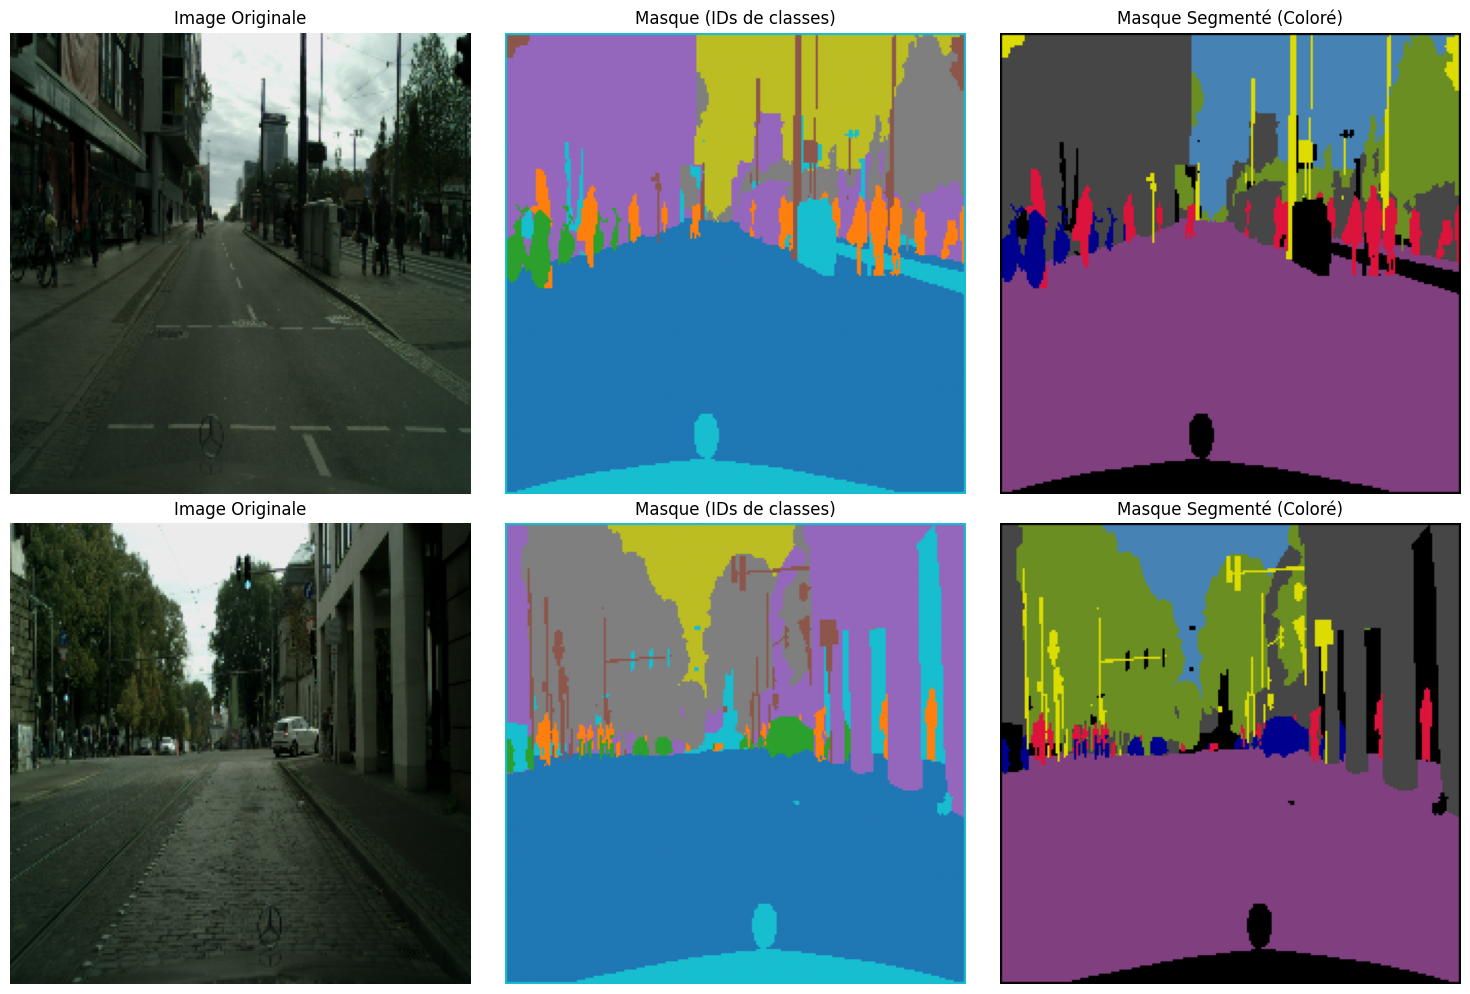


Classes présentes dans la première image:
  flat: 23640 pixels (47.1%)
  human: 1629 pixels (3.2%)
  vehicle: 771 pixels (1.5%)
  construction: 9749 pixels (19.4%)
  object: 1100 pixels (2.2%)
  nature: 3469 pixels (6.9%)
  sky: 5399 pixels (10.8%)
  void: 4419 pixels (8.8%)

📊 Échantillon du dataset de validation:


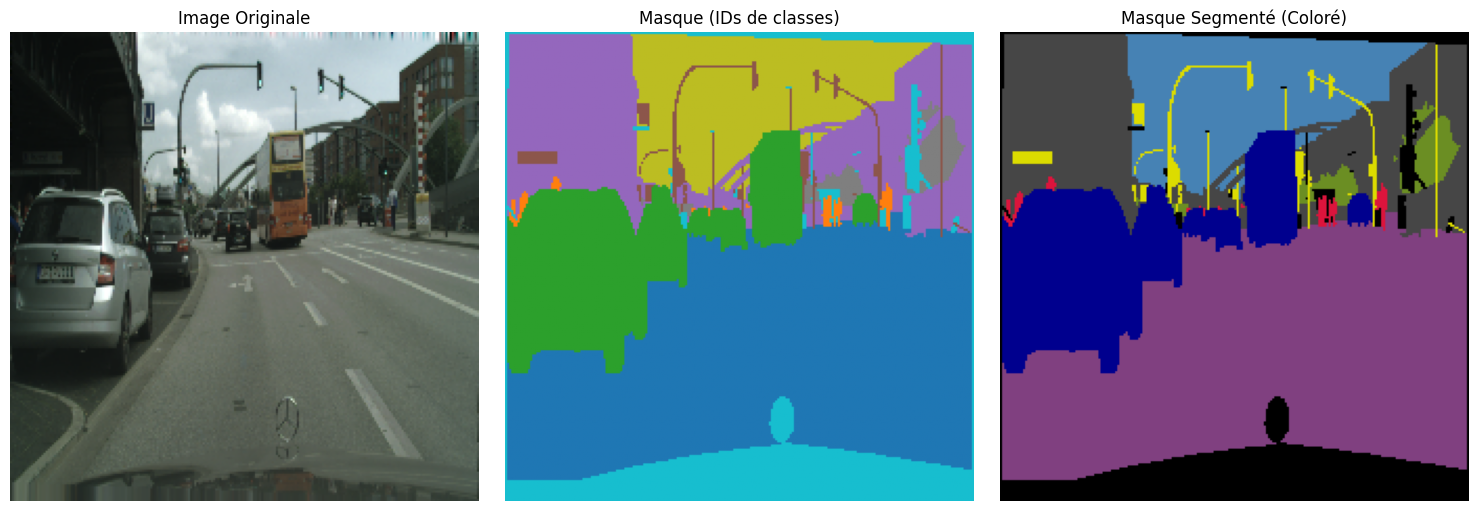


Classes présentes dans la première image:
  flat: 19593 pixels (39.0%)
  human: 269 pixels (0.5%)
  vehicle: 7581 pixels (15.1%)
  construction: 8500 pixels (16.9%)
  object: 942 pixels (1.9%)
  nature: 834 pixels (1.7%)
  sky: 6339 pixels (12.6%)
  void: 6118 pixels (12.2%)

🧪 Échantillon du dataset de test:


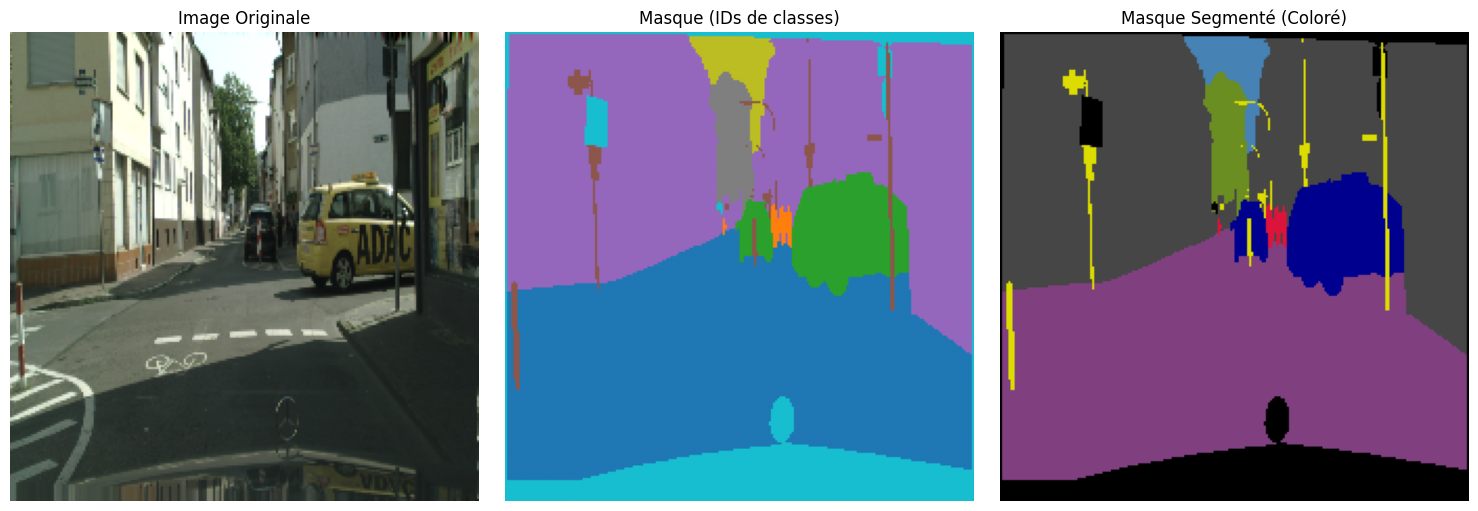


Classes présentes dans la première image:
  flat: 18943 pixels (37.8%)
  human: 165 pixels (0.3%)
  vehicle: 2759 pixels (5.5%)
  construction: 19632 pixels (39.1%)
  object: 873 pixels (1.7%)
  nature: 1013 pixels (2.0%)
  sky: 883 pixels (1.8%)
  void: 5908 pixels (11.8%)


In [19]:
# ============================================================
# Visualisation des échantillons
# ============================================================

print("\n" + "=" * 80)
print("🖼️ VISUALISATION DES ÉCHANTILLONS")
print("=" * 80)

print("\n📚 Échantillon du dataset d'entraînement:")
display_sample(train_dataset, num_samples=2)

print("\n📊 Échantillon du dataset de validation:")
display_sample(val_dataset, num_samples=1)

print("\n🧪 Échantillon du dataset de test:")
display_sample(test_dataset, num_samples=1)

In [20]:
# ============================================================
# ENTRAÎNEMENT MULTI-EXPÉRIENCES
# ============================================================

# ✅ Contrôle de l'entraînement
TRAIN = True  # ⚠️ Mettre à False pour sauter l'entraînement

# ✅ Choisir quelle(s) expérience(s) lancer
EXPERIMENTS_TO_RUN = [
    "exp_001_miniunet",           # Baseline from scratch
    "exp_002_no_augmentation",  # MobileNetV2 frozen
    "exp_003_finetune"          # MobileNetV2 fine-tuning
]

if TRAIN:
    print("\n" + "=" * 90)
    print("🚀 LANCEMENT DES ENTRAÎNEMENTS")
    print("=" * 90)
    
    for exp_name in EXPERIMENTS_TO_RUN:
        if exp_name not in EXPERIMENTS:
            print(f"⚠️ Expérience inconnue : {exp_name}")
            continue
        
        config = EXPERIMENTS[exp_name]
        params = config["params"]
        
        print(f"\n{'='*90}")
        print(f"🔬 Expérience : {exp_name}")
        print(f"📝 Description : {config['description']}")
        print(f"📊 Paramètres :")
        for key, value in params.items():
            print(f"   • {key}: {value}")
        print(f"{'='*90}\n")
        
        # Créer la structure de dossiers
        exp_paths = setup_experiment_paths(BASE_DIR, exp_name)
        
        # Créer le modèle
        print("🏗️ Construction du modèle...")
        model = config["model_builder"]()
        print(f"✅ Modèle créé : {model.name}")
        print(f"   📊 Paramètres : {model.count_params():,}")
        
        # Entraîner le modèle
        print("\n🚀 Début de l'entraînement...\n")
        
        try:
            history = train_model_with_config(
                model,
                train_dataset,
                val_dataset,
                config,
                exp_paths,
                exp_name
            )
            
            print(f"\n✅ Expérience {exp_name} terminée avec succès !")
            print(f"📁 Résultats sauvegardés dans : {exp_paths['exp_dir']}")
            
            # Afficher les meilleurs résultats
            if 'val_iou' in history.history:
                best_iou = max(history.history['val_iou'])
                best_epoch = history.history['val_iou'].index(best_iou) + 1
                print(f"🏆 Meilleur IoU validation : {best_iou:.4f} (époque {best_epoch})")
            
        except Exception as e:
            print(f"\n❌ Erreur lors de l'entraînement de {exp_name} :")
            print(f"   {str(e)}")
            import traceback
            traceback.print_exc()
        
        print("\n" + "=" * 90)
    
    print("\n✅ Tous les entraînements terminés !")

else:
    print("\n⏭️ Entraînement désactivé (TRAIN = False)")


🚀 LANCEMENT DES ENTRAÎNEMENTS

🔬 Expérience : exp_001_miniunet
📝 Description : MiniUNet baseline entraîné from scratch (aucun encoder pré-entraîné)
📊 Paramètres :
   • learning_rate: 0.001
   • batch_size: 8
   • epochs: 15
   • base_model_trainable: True
   • validation_split: 0.2
   • augmentation: False

🏗️ Construction du modèle...


2025/11/02 18:43:52 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



✅ Modèle créé : MiniUNet
   📊 Paramètres : 487,416

🚀 Début de l'entraînement...

🚀 Starting training for experiment: exp_001_miniunet
📝 Description: MiniUNet baseline entraîné from scratch (aucun encoder pré-entraîné)
📊 Parameters: {'learning_rate': 0.001, 'batch_size': 8, 'epochs': 15, 'base_model_trainable': True, 'validation_split': 0.2, 'augmentation': False}
Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4784 - iou: 0.1276 - loss: 1.4642
Epoch 1: val_iou improved from None to 0.39332, saving model to C:\Users\touad\Projects-Openclassrooms\Projet-Future-Vision-Transport\experiments\exp_001_miniunet\models\checkpoints\best_model.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.5834 - iou: 0.2155 - loss: 1.1744 - val_accuracy: 0.7022 - val_iou: 0.3933 - val_loss: 0.8550 - learning_rate: 0.0010
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.7098 - iou: 0.3828 - loss: 0.8046
Epoch 2: val_iou improved from 0.39332 to 0.47336, saving m

In [21]:
# ============================================================
# Fonction d'évaluation d'une expérience
# ============================================================

def load_and_evaluate_experiment(experiment_name, test_dataset, base_dir):
    """
    Charge un modèle sauvegardé et l'évalue sur le dataset de test.
    """
    print(f"\n{'='*80}")
    print(f"📂 ÉVALUATION DU MODÈLE : {experiment_name}")
    print(f"{'='*80}")
    
    model_path = os.path.join(base_dir, "experiments", experiment_name, "models", "cityscapes_segmentation_model.keras")
    
    print(f"📁 Chargement du modèle depuis : {model_path}")
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"❌ Modèle non trouvé : {model_path}")
    
    model = tf.keras.models.load_model(model_path)
    print(f"✅ Modèle '{experiment_name}' chargé avec succès !")
    print(f"   🏗️ Architecture : {model.name}")
    print(f"   📊 Paramètres : {model.count_params():,}")
    
    config_path = os.path.join(base_dir, "experiments", experiment_name, "results", "experiment_config.json")
    description = "N/A"
    if os.path.exists(config_path):
        with open(config_path, 'r', encoding='utf-8') as f:
            config = json.load(f)
            description = config.get('description', 'N/A')
    
    print(f"📝 Description : {description}")
    
    print(f"\n🧪 Évaluation sur le dataset de test...")
    test_results = model.evaluate(test_dataset, verbose=1)
    
    results_dict = {f"test_{name}": float(val) for name, val in zip(model.metrics_names, test_results)}
    
    print(f"\n📊 RÉSULTATS FINAUX :")
    for k, v in results_dict.items():
        if 'iou' in k.lower():
            print(f"   🏆 {k}: {v:.4f} ⭐ (KPI Principal)")
        else:
            print(f"   📈 {k}: {v:.4f}")
    
    test_results_path = os.path.join(base_dir, "experiments", experiment_name, "results", "test_results.json")
    os.makedirs(os.path.dirname(test_results_path), exist_ok=True)
    with open(test_results_path, 'w', encoding='utf-8') as f:
        json.dump({
            'test_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'results': results_dict
        }, f, indent=4)
    
    print(f"\n💾 Résultats sauvegardés dans : {test_results_path}")
    print(f"{'='*80}\n")
    
    return results_dict, model

print("✅ Fonction d'évaluation définie")

✅ Fonction d'évaluation définie


In [22]:
# ============================================================
# Évaluation détaillée avec métriques complètes (PARTIE 1)
# ============================================================

def detailed_evaluation(model, test_dataset, class_names, class_colors, experiment_name=None, save_dir=None):
    """Évaluation détaillée du modèle avec métriques complètes"""
    
    if save_dir is None and experiment_name:
        save_dir = os.path.join(BASE_DIR, "experiments", experiment_name, "results")
    elif save_dir is None:
        save_dir = os.path.join(BASE_DIR, "evaluation_results")
    
    os.makedirs(save_dir, exist_ok=True)
    
    print("\n" + "=" * 80)
    print("🔬 ÉVALUATION DÉTAILLÉE DU MODÈLE")
    print("=" * 80)
    print(f"📁 Répertoire de sauvegarde: {save_dir}")
    
    # 1. Métriques de base
    print("\n📊 1. MÉTRIQUES DE BASE")
    test_results = model.evaluate(test_dataset, verbose=1)
    
    base_metrics_df = pd.DataFrame({
        'Métrique': model.metrics_names,
        'Valeur': test_results
    })
    
    print("\n📋 Métriques de base:")
    print(base_metrics_df.to_string(index=False, float_format='%.4f'))
    
    base_metrics_path = os.path.join(save_dir, "base_metrics.csv")
    base_metrics_df.to_csv(base_metrics_path, index=False)
    print(f"💾 Sauvegardé: {base_metrics_path}")
    
    # 2. Collecte des prédictions
    print("\n🎯 2. COLLECTE DES PRÉDICTIONS")
    all_true_masks = []
    all_pred_masks = []
    all_images = []
    
    print("   Traitement des batches...")
    for batch_idx, (images, true_masks) in enumerate(test_dataset):
        predictions = model.predict(images, verbose=0)
        pred_masks = tf.argmax(predictions, axis=-1)
        
        all_images.extend(images.numpy())
        all_true_masks.extend(true_masks.numpy())
        all_pred_masks.extend(pred_masks.numpy())
        
        if batch_idx % 10 == 0:
            print(f"   ✅ Batch {batch_idx + 1} traité...")
    
    all_true_masks = np.array(all_true_masks)
    all_pred_masks = np.array(all_pred_masks)
    all_images = np.array(all_images)
    print(f"   Total d'images évaluées: {len(all_true_masks)}")
    
    # 3. IoU par classe (KPI PRINCIPAL)
    print("\n🏆 3. IoU PAR CLASSE (KPI PRINCIPAL)")
    
    iou_data = []
    ious = []
    total_pixels = all_true_masks.size
    
    for class_id in range(len(class_names)):
        true_binary = (all_true_masks == class_id)
        pred_binary = (all_pred_masks == class_id)
        
        intersection = np.logical_and(true_binary, pred_binary).sum()
        union = np.logical_or(true_binary, pred_binary).sum()
        
        if union > 0:
            iou = intersection / union
        else:
            iou = 0.0
        
        ious.append(iou)
        
        iou_data.append({
            'Classe': class_names[class_id],
            'IoU': iou,
            'Pixels_Vrais_%': 100 * true_binary.sum() / total_pixels,
            'Pixels_Prédits_%': 100 * pred_binary.sum() / total_pixels
        })
    
    iou_df = pd.DataFrame(iou_data)
    mean_iou = np.mean(ious)
    
    print("\n📊 Tableau IoU par classe:")
    print(iou_df.to_string(index=False, float_format='%.4f'))
    print(f"\n🎯 MEAN IoU (KPI GLOBAL): {mean_iou:.4f}")
    
    iou_path = os.path.join(save_dir, "iou_per_class.csv")
    iou_df.to_csv(iou_path, index=False)
    print(f"💾 Sauvegardé: {iou_path}")
    
    return all_true_masks, all_pred_masks, all_images, iou_df, mean_iou

print("✅ Fonction detailed_evaluation (partie 1) définie")

✅ Fonction detailed_evaluation (partie 1) définie


In [23]:
# ============================================================
# Évaluation détaillée - Suite (PARTIE 2)
# ============================================================

def complete_detailed_evaluation(all_true_masks, all_pred_masks, all_images, 
                                 class_names, class_colors, iou_df, mean_iou, save_dir):
    """Complète l'évaluation détaillée avec rapport de classification et confusion matrix"""
    
    # 4. Rapport de classification
    print("\n📋 4. RAPPORT DE CLASSIFICATION")
    
    y_true_flat = all_true_masks.flatten()
    y_pred_flat = all_pred_masks.flatten()
    
    report = classification_report(
        y_true_flat,
        y_pred_flat,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    
    classification_df = pd.DataFrame([
        {
            'Classe': cls,
            'Précision': m['precision'],
            'Rappel': m['recall'],
            'F1-Score': m['f1-score'],
            'Support': int(m['support'])
        }
        for cls, m in report.items() if cls not in ('accuracy', 'macro avg', 'weighted avg')
    ])
    
    print("\n📊 Rapport de classification:")
    print(classification_df.to_string(index=False, float_format='%.4f'))
    
    classification_path = os.path.join(save_dir, "classification_report.csv")
    classification_df.to_csv(classification_path, index=False)
    print(f"💾 Sauvegardé: {classification_path}")
    
    # 5. Matrice de confusion
    print("\n📢 5. MATRICE DE CONFUSION")
    cm = confusion_matrix(y_true_flat, y_pred_flat)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    
    print("\n📊 Matrice de confusion:")
    print(cm_df.to_string())
    
    cm_path = os.path.join(save_dir, "confusion_matrix.csv")
    cm_df.to_csv(cm_path)
    print(f"💾 Sauvegardé: {cm_path}")
    
    # Visualiser la matrice de confusion
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Matrice de Confusion')
    plt.xlabel('Prédictions')
    plt.ylabel('Vérité terrain')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    cm_viz_path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(cm_viz_path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Visualisation sauvegardée: {cm_viz_path}")
    plt.show()
    
    # 6. Visualisation des prédictions
    print("\n🖼️ 6. EXEMPLES DE PRÉDICTIONS")
    visualize_predictions_detailed(all_images, all_true_masks, all_pred_masks,
                                 class_names, class_colors, num_samples=5, save_dir=save_dir)
    
    print(f"\n✅ Évaluation terminée. Tous les fichiers sauvegardés dans: {save_dir}")
    
    return {
        "accuracy": report["accuracy"],
        "mean_iou": mean_iou,
        "iou_df": iou_df,
        "classification_df": classification_df,
        "cm_df": cm_df
    }


def visualize_predictions_detailed(images, true_masks, pred_masks, class_names, class_colors, num_samples=5, save_dir=None):
    """Visualise des exemples de prédictions"""
    indices = np.random.choice(len(images), size=min(num_samples, len(images)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4*num_samples))
    
    for i, idx in enumerate(indices):
        axes[i, 0].imshow((images[idx] * 255).astype(np.uint8))
        axes[i, 0].set_title(f"Image Originale #{idx}")
        axes[i, 0].axis('off')
        
        true_colored = np.zeros((*true_masks[idx].shape, 3), dtype=np.uint8)
        for class_id in range(len(class_names)):
            true_colored[true_masks[idx] == class_id] = class_colors[class_id]
        
        axes[i, 1].imshow(true_colored)
        axes[i, 1].set_title("Vérité Terrain")
        axes[i, 1].axis('off')
        
        pred_colored = np.zeros((*pred_masks[idx].shape, 3), dtype=np.uint8)
        for class_id in range(len(class_names)):
            pred_colored[pred_masks[idx] == class_id] = class_colors[class_id]
        
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title("Prédiction")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_dir:
        out_path = os.path.join(save_dir, "prediction_examples.png")
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"🖼️ Exemples de prédictions sauvegardés: {out_path}")
    
    plt.show()

print("✅ Fonctions d'évaluation détaillée (partie 2) définies")

✅ Fonctions d'évaluation détaillée (partie 2) définies


In [24]:
# ============================================================
# Comparaison des expériences
# ============================================================

def compare_experiments(base_dir):
    """Compare les résultats de plusieurs expériences (Focus sur IoU)"""
    experiments_dir = os.path.join(base_dir, "experiments")
    
    if not os.path.exists(experiments_dir):
        print("❌ Aucune expérience trouvée")
        return
    
    results = []
    
    print(f"🔍 Analyse des expériences dans : {experiments_dir}")
    
    for exp_name in os.listdir(experiments_dir):
        exp_path = os.path.join(experiments_dir, exp_name)
        config_path = os.path.join(exp_path, "results", "experiment_config.json")
        history_path = os.path.join(exp_path, "results", "training_history.json")
        
        if not os.path.isdir(exp_path):
            continue
        
        if os.path.exists(config_path) and os.path.exists(history_path):
            try:
                with open(config_path, 'r', encoding='utf-8') as f:
                    config = json.load(f)
                with open(history_path, 'r', encoding='utf-8') as f:
                    history = json.load(f)
                
                final_metrics = {
                    'experiment': exp_name,
                    'description': config.get('description', ''),
                    'epochs_trained': len(history['loss'])
                }
                
                if 'iou' in history and 'val_iou' in history:
                    final_metrics.update({
                        'final_train_iou': history['iou'][-1],
                        'final_val_iou': history['val_iou'][-1],
                        'best_val_iou': max(history['val_iou']),
                    })
                
                if 'accuracy' in history:
                    final_metrics.update({
                        'final_train_acc': history.get('accuracy', [0])[-1],
                        'final_val_acc': history.get('val_accuracy', [0])[-1],
                        'best_val_acc': max(history.get('val_accuracy', [0]))
                    })
                
                final_metrics.update({
                    'final_train_loss': history['loss'][-1],
                    'final_val_loss': history['val_loss'][-1],
                })
                
                results.append(final_metrics)
            
            except Exception as e:
                print(f"⚠️ Erreur lors du traitement de {exp_name}: {e}")
        else:
            print(f"ℹ️ Pas de fichiers de résultats dans {exp_name}")
    
    if not results:
        print("❌ Aucune expérience complète trouvée.")
        return
    
    print("\n" + "=" * 100)
    print("🏆 COMPARAISON DES EXPÉRIENCES (classées par IoU)")
    print("=" * 100)
    
    for result in sorted(results, key=lambda x: x.get('best_val_iou', 0), reverse=True):
        print(f"\n📊 {result['experiment']}")
        print(f"   📝 Description     : {result['description']}")
        
        if 'best_val_iou' in result:
            print(f"   🏆 Best Val IoU     : {result['best_val_iou']:.4f} ⭐ (KPI)")
            print(f"   📈 Final Val IoU    : {result['final_val_iou']:.4f}")
        
        if 'best_val_acc' in result:
            print(f"   ✅ Best Val Acc     : {result['best_val_acc']:.4f}")
        
        print(f"   📉 Final Val Loss   : {result['final_val_loss']:.4f}")
        print(f"   ⏱️ Époques entraînées : {result['epochs_trained']}")
        print("-" * 100)
    
    return results

print("✅ Fonction de comparaison définie")

✅ Fonction de comparaison définie


In [25]:
# ============================================================
# Fonctions de prédiction sur nouvelles images (PARTIE 1)
# ============================================================

def load_model_and_config(experiment_name, base_dir=None):
    """Charge le modèle et la configuration depuis une expérience"""
    if base_dir is None:
        base_dir = BASE_DIR
    
    model_path = os.path.join(base_dir, "experiments", experiment_name, "models", "cityscapes_segmentation_model.keras")
    config_path = os.path.join(base_dir, "experiments", experiment_name, "models", "class_mapping.json")
    
    print(f"📁 Chargement depuis l'expérience: {experiment_name}")
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"❌ Modèle non trouvé: {model_path}")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"❌ Configuration non trouvée: {config_path}")
    
    print(f"🤖 Chargement du modèle...")
    model = tf.keras.models.load_model(model_path)
    print(f"✅ Modèle chargé: {model.name}")
    print(f"   📊 Paramètres: {model.count_params():,}")
    
    print(f"⚙️ Chargement de la configuration...")
    with open(config_path, 'r', encoding='utf-8') as f:
        config = json.load(f)
    
    config['id_to_group'] = np.array(config['id_to_group'], dtype=np.uint8)
    
    print(f"✅ Configuration chargée:")
    print(f"   Classes: {config['num_classes']}")
    print(f"   Groupes: {config['group_names']}")
    
    return model, config

print("✅ Fonction load_model_and_config définie")

✅ Fonction load_model_and_config définie


In [26]:
# ============================================================
# Fonctions de prédiction (PARTIE 2)
# ============================================================

def predict_single_image(model, config, image_path=None, image_array=None, img_size=(224, 224)):
    """Réalise une prédiction sur une seule image"""
    if image_path is None and image_array is None:
        raise ValueError("Il faut fournir soit image_path soit image_array")
    
    if image_path is not None and image_array is not None:
        raise ValueError("Ne fournir qu'un seul type d'entrée: image_path OU image_array")
    
    if image_path is not None:
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image non trouvée: {image_path}")
        
        print(f"📷 Chargement de l'image: {os.path.basename(image_path)}")
        image_pil = Image.open(image_path).convert('RGB')
        image_array = np.array(image_pil)
    
    print(f"🔄 Préprocessing de l'image...")
    print(f"   Taille originale: {image_array.shape}")
    
    image_resized = tf.image.resize(image_array, img_size, method='bilinear')
    image_normalized = tf.cast(image_resized, tf.float32) / 255.0
    image_batch = tf.expand_dims(image_normalized, axis=0)
    
    print(f"   Taille pour prédiction: {image_batch.shape}")
    
    print(f"🧠 Prédiction en cours...")
    predictions = model.predict(image_batch, verbose=0)
    pred_mask = tf.argmax(predictions, axis=-1)[0].numpy()
    
    unique_classes, counts = np.unique(pred_mask, return_counts=True)
    total_pixels = pred_mask.size
    
    class_stats = []
    for class_id, count in zip(unique_classes, counts):
        class_name = config['group_names'][class_id]
        percentage = (count / total_pixels) * 100
        class_stats.append({
            'class_id': int(class_id),
            'class_name': class_name,
            'pixel_count': int(count),
            'percentage': percentage
        })
    
    class_stats.sort(key=lambda x: x['percentage'], reverse=True)
    
    print(f"✅ Prédiction terminée!")
    print(f"📊 Classes détectées:")
    for stat in class_stats:
        print(f"   {stat['class_name']:>12}: {stat['pixel_count']:>8} pixels ({stat['percentage']:>5.1f}%)")
    
    return {
        'original_image': image_array,
        'processed_image': image_normalized.numpy(),
        'predictions_raw': predictions[0],
        'prediction_mask': pred_mask,
        'class_statistics': class_stats,
        'image_path': image_path,
        'input_size': img_size
    }

print("✅ Fonction predict_single_image définie")

✅ Fonction predict_single_image définie


In [27]:
# ============================================================
# Fonctions de prédiction (PARTIE 3)
# ============================================================

def predict_from_test_dataset(model, config, test_dataset, image_index=0):
    """Fait une prédiction sur une image du dataset de test"""
    print(f"🔍 Extraction de l'image index {image_index} depuis le dataset de test...")
    
    current_index = 0
    
    for batch_idx, (images, true_masks) in enumerate(test_dataset):
        batch_size = images.shape[0]
        batch_start = current_index
        batch_end = current_index + batch_size
        
        if batch_start <= image_index < batch_end:
            local_idx = image_index - batch_start
            
            image = images[local_idx].numpy()
            true_mask = true_masks[local_idx].numpy()
            
            print(f"📸 Image trouvée dans le batch {batch_idx} (position locale {local_idx})")
            
            image_for_pred = tf.expand_dims(images[local_idx], axis=0)
            predictions = model.predict(image_for_pred, verbose=0)
            pred_mask = tf.argmax(predictions, axis=-1)[0].numpy()
            
            unique_pred, counts_pred = np.unique(pred_mask, return_counts=True)
            unique_true, counts_true = np.unique(true_mask, return_counts=True)
            total_pixels = pred_mask.size
            
            class_stats = []
            for class_id in range(config['num_classes']):
                class_name = config['group_names'][class_id]
                
                pred_count = counts_pred[unique_pred == class_id][0] if class_id in unique_pred else 0
                true_count = counts_true[unique_true == class_id][0] if class_id in unique_true else 0
                
                class_stats.append({
                    'class_id': int(class_id),
                    'class_name': class_name,
                    'predicted_pixels': int(pred_count),
                    'true_pixels': int(true_count),
                    'predicted_percentage': (pred_count / total_pixels) * 100,
                    'true_percentage': (true_count / total_pixels) * 100
                })
            
            print(f"✅ Prédiction terminée sur image index {image_index}")
            print("📊 Statistiques (Top 5 classes prédominantes) :")
            for stat in sorted(class_stats, key=lambda x: x['predicted_percentage'], reverse=True)[:5]:
                print(f"   {stat['class_name']:<15} → {stat['predicted_percentage']:.2f}%")
            
            return {
                'original_image': (image * 255).astype(np.uint8),
                'prediction_mask': pred_mask,
                'true_mask': true_mask,
                'predictions_raw': predictions[0],
                'class_statistics': class_stats,
                'image_index': image_index
            }
        
        current_index += batch_size
    
    raise IndexError(f"❌ Image index {image_index} non trouvée dans le dataset ({current_index} images disponibles).")


def visualize_prediction(prediction_result, config, save_path=None):
    """Visualise le résultat d'une prédiction"""
    if 'prediction_mask' not in prediction_result:
        raise ValueError("❌ Le dictionnaire fourni ne contient pas de clé 'prediction_mask'.")
    
    print("🖼️ Visualisation de la prédiction en cours...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(prediction_result['original_image'])
    axes[0].set_title("Image Originale", fontsize=13)
    axes[0].axis("off")
    
    im = axes[1].imshow(
        prediction_result['prediction_mask'],
        cmap='tab10',
        vmin=0,
        vmax=config['num_classes'] - 1
    )
    axes[1].set_title("Masque Prédictif (IDs)", fontsize=13)
    axes[1].axis("off")
    
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_ticks(range(config['num_classes']))
    cbar.set_ticklabels(config['group_names'])
    cbar.ax.tick_params(labelsize=8)
    
    pred_colored = np.zeros((*prediction_result['prediction_mask'].shape, 3), dtype=np.uint8)
    for class_id in range(config['num_classes']):
        mask = prediction_result['prediction_mask'] == class_id
        if np.any(mask):
            pred_colored[mask] = config['group_colors'][class_id]
    
    axes[2].imshow(pred_colored)
    axes[2].set_title("Masque Coloré (Légende Réelle)", fontsize=13)
    axes[2].axis("off")
    
    top_class = prediction_result['class_statistics'][0]
    plt.suptitle(
        f"🏷️ Classe dominante : {top_class['class_name']} ({top_class['percentage']:.1f}%)",
        fontsize=14,
        fontweight='bold'
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"💾 Visualisation sauvegardée dans : {save_path}")
    
    plt.show()
    
    stats_df = pd.DataFrame(prediction_result['class_statistics'])
    print("\n📊 Statistiques détaillées par classe :")
    print(stats_df[['class_name', 'pixel_count', 'percentage']].to_string(index=False, float_format="%.2f"))

print("✅ Fonctions de prédiction (partie 3) définies")

✅ Fonctions de prédiction (partie 3) définies


In [28]:
# ============================================================
# Génération de rapport final
# ============================================================

def generate_final_report(experiment_name, base_dir):
    """Génère un rapport Markdown complet d'une expérience (Focus sur IoU)"""
    
    exp_dir = os.path.join(base_dir, "experiments", experiment_name)
    results_dir = os.path.join(exp_dir, "results")
    config_path = os.path.join(results_dir, "experiment_config.json")
    test_results_path = os.path.join(results_dir, "test_results.json")
    history_path = os.path.join(results_dir, "training_history.json")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"❌ Fichier de configuration introuvable : {config_path}")
    
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
    
    test_results = {}
    if os.path.exists(test_results_path):
        with open(test_results_path, "r", encoding="utf-8") as f:
            test_results = json.load(f)
    
    training_epochs = "N/A"
    if os.path.exists(history_path):
        with open(history_path, "r", encoding="utf-8") as f:
            history_data = json.load(f)
        training_epochs = len(history_data.get('loss', []))
    
    exp_name_val = config.get("exp_name", experiment_name)
    desc = config.get("description", "N/A")
    params = config.get("params", {})
    date_eval = test_results.get("test_date", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    
    metrics = test_results.get("results", {})
    loss = metrics.get("test_loss", "N/A")
    accuracy = metrics.get("test_accuracy", "N/A")
    iou = metrics.get("test_iou", "N/A")
    
    loss_str = f"{loss:.4f}" if isinstance(loss, (int, float)) else loss
    accuracy_str = f"{accuracy:.4f}" if isinstance(accuracy, (int, float)) else accuracy
    iou_str = f"{iou:.4f}" if isinstance(iou, (int, float)) else iou
    
    rapport_md = f"""# Rapport d'Évaluation - Modèle de Segmentation Sémantique

## 🏷️ Identification de l'Expérience
- **Nom de l'expérience**: {exp_name_val}
- **Description**: {desc}
- **Date d'évaluation**: {date_eval}

## ⚙️ Configuration du Modèle
- **Architecture**: MobileNetV2-UNet (ou MiniUNet selon l'expérience)
- **Backbone**: MobileNetV2 (ImageNet pré-entraîné) ou from scratch
- **Encoder trainable**: {params.get("base_model_trainable", "N/A")}
- **Classes de segmentation**: 8 groupes
- **Groupes de classes**: flat, human, vehicle, construction, object, nature, sky, void

## 📋 Paramètres d'Entraînement
- **Taille d'image**: {IMG_SIZE}
- **Batch size**: {params.get("batch_size", "N/A")}
- **Époques d'entraînement**: {training_epochs}
- **Taux d'apprentissage**: {params.get("learning_rate", "N/A")}
- **Division validation**: {params.get("validation_split", "N/A")}
- **Augmentation de données**: {params.get("augmentation", "N/A")}

## 🏆 Performances Finales sur Dataset de Test

### 📊 KPI Principal : IoU (Intersection over Union)
- **Mean IoU final**: **{iou_str}** ⭐

### 📈 Métriques Secondaires
- **Perte finale**: {loss_str}
- **Précision finale**: {accuracy_str}

## 🎯 Dataset et Évaluation
- **Dataset**: Cityscapes (segmentation urbaine)
- **Split utilisé pour test**: Dataset 'val' original (~500 images)
- **Méthode d'évaluation**: IoU par classe, précision globale, matrice de confusion

## 📈 Mapping des Classes
Les 30+ classes originales de Cityscapes ont été regroupées en 8 catégories :

1. **Flat** (0): Routes, trottoirs, parkings
2. **Human** (1): Personnes, cyclistes
3. **Vehicle** (2): Voitures, camions, bus, motos, vélos
4. **Construction** (3): Bâtiments, murs, clôtures, ponts
5. **Object** (4): Poteaux, panneaux, feux de circulation
6. **Nature** (5): Végétation, terrain
7. **Sky** (6): Ciel
8. **Void** (7): Pixels non étiquetés ou hors région d'intérêt

## 🚗 Applications et Déploiement
- **Cas d'usage**: Système de vision pour véhicules autonomes
- **Format de modèle**: Keras (.keras) - compatible TensorFlow Lite
- **Optimisations**: MobileNetV2 conçu pour l'efficacité mobile
- **Intégration**: API FastAPI + Frontend Next.js (en développement)

## 📂 Artefacts Générés
- **Modèle entraîné**: `experiments/{experiment_name}/models/cityscapes_segmentation_model.keras`
- **Configuration**: `experiments/{experiment_name}/results/experiment_config.json`
- **Historique d'entraînement**: `experiments/{experiment_name}/results/training_history.json`
- **Métriques détaillées**: `experiments/{experiment_name}/results/`
- **Visualisations**: Matrice de confusion, exemples de prédictions

## 📄 Suivi et Reproductibilité
- **Structure d'expériences**: Organisation modulaire par dossiers
- **Intégration MLflow**: Suivi des métriques et artefacts
- **Graine aléatoire**: 42 (reproductibilité garantie)
- **Environnement**: TensorFlow {tf.__version__}, Keras {keras.__version__}

## 📝 Notes Techniques
- Le modèle utilise `SparseCategoricalCrossentropy` comme fonction de perte
- **IoU (Intersection over Union)** est la métrique principale de performance
- L'encoder MobileNetV2 peut être gelé ou entraînable selon la configuration
- La segmentation est réalisée à 224x224 puis peut être redimensionnée
- L'augmentation de données inclut flip horizontal et variation de luminosité

## 🎯 Recommandations
1. **Pour améliorer les performances**: Entraîner avec encoder dégelé ou plus d'epochs
2. **Pour le déploiement**: Conversion en TensorFlow Lite pour usage mobile embarqué
3. **Pour l'évaluation**: Comparer Mean IoU entre expériences pour analyse
4. **Pour la production**: Étendre l'entraînement à d'autres environnements urbains

---
*Rapport généré automatiquement le {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}*
"""
    
    rapport_path = os.path.join(results_dir, "rapport_final.md")
    with open(rapport_path, 'w', encoding='utf-8') as f:
        f.write(rapport_md)
    
    print(f"✅ Rapport Markdown généré : {rapport_path}")
    
    rapport_json = {
        "experiment_name": exp_name_val,
        "description": desc,
        "evaluation_date": date_eval,
        "model_config": {
            "architecture": "MobileNetV2-UNet",
            "num_classes": 8,
            "class_names": group_names,
            "input_size": IMG_SIZE
        },
        "training_params": params,
        "final_performance": {
            "loss": loss if isinstance(loss, (int, float)) else None,
            "accuracy": accuracy if isinstance(accuracy, (int, float)) else None,
            "mean_iou": iou if isinstance(iou, (int, float)) else None
        }
    }
    
    rapport_json_path = os.path.join(results_dir, "rapport_final.json")
    with open(rapport_json_path, "w", encoding="utf-8") as f:
        json.dump(rapport_json, f, indent=4, ensure_ascii=False)
    
    print(f"📊 Rapport JSON sauvegardé : {rapport_json_path}")
    
    return rapport_md

print("✅ Fonction de génération de rapport définie")

✅ Fonction de génération de rapport définie
